In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os

In [2]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

In [3]:
work_dir = "/share/crsp/lab/dalawson/share/1_Lab_sequencing/1_Tatyana/Cellranger/large_and_smallest_tumors_cellplex7/outs/per_sample_outs/"

In [4]:
adata_1 = sc.read_10x_h5(os.path.join(work_dir, 'possible_smallest_tumor/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_1.obs["orig_ident"] = "tum_or_pMFP_654"
adata_1.var_names_make_unique()
adata_1

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 1976 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
adata_2 = sc.read_10x_h5(os.path.join(work_dir, 'tumor_081720/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_2.obs["orig_ident"] = "tum_081720"
adata_2.var_names_make_unique()
adata_2

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3454 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [6]:
adata_3 = sc.read_10x_h5(os.path.join(work_dir, 'tumor_120519/count/sample_filtered_feature_bc_matrix.h5'),
    gex_only=True
)
adata_3.obs["orig_ident"] = "tum_120519"
adata_3.var_names_make_unique()
adata_3

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3530 × 32285
    obs: 'orig_ident'
    var: 'gene_ids', 'feature_types', 'genome'

In [7]:
adatas = [adata_1, adata_2, adata_3]
adata = ad.concat(adatas,  join="outer")
adata

AnnData object with n_obs × n_vars = 8960 × 32285
    obs: 'orig_ident'

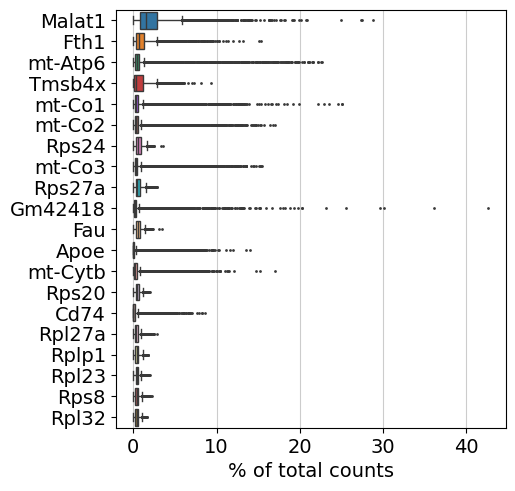

In [8]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [9]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=1)
adata

AnnData object with n_obs × n_vars = 8684 × 26314
    obs: 'orig_ident', 'n_genes'
    var: 'n_cells'

In [10]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))
adata.var["hb"] = adata.var_names.str.startswith("Hbb")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

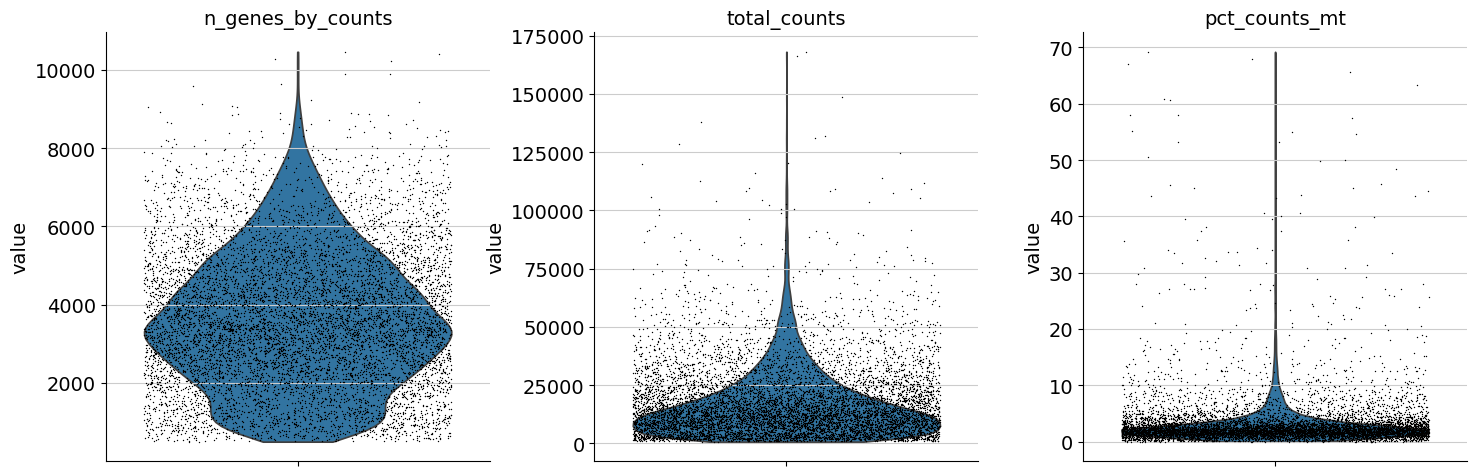

In [11]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

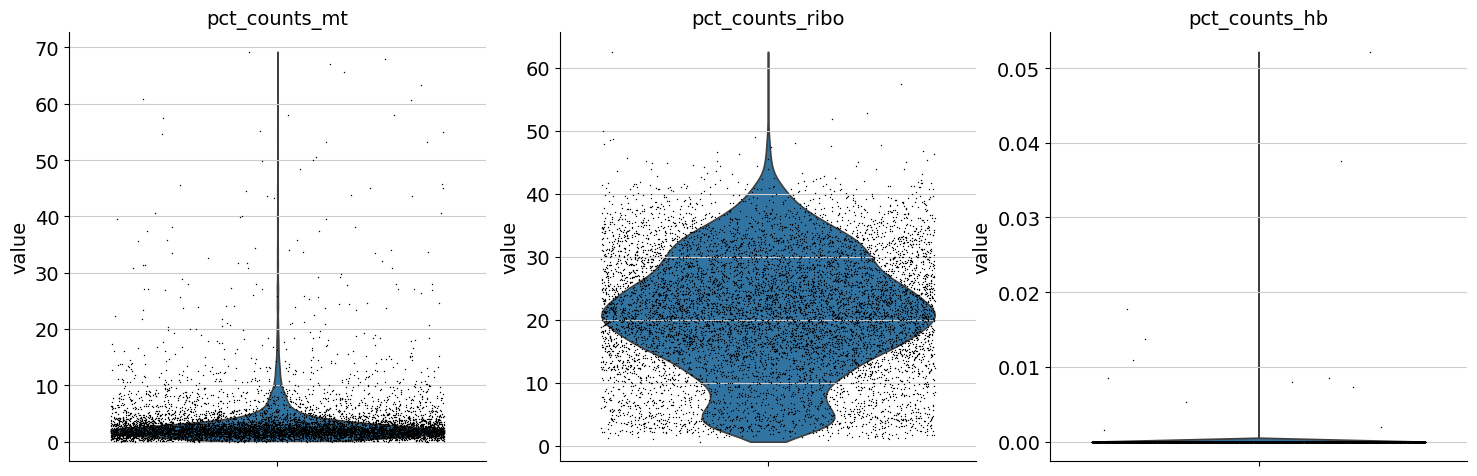

In [12]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

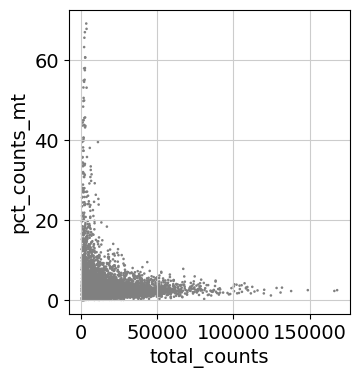

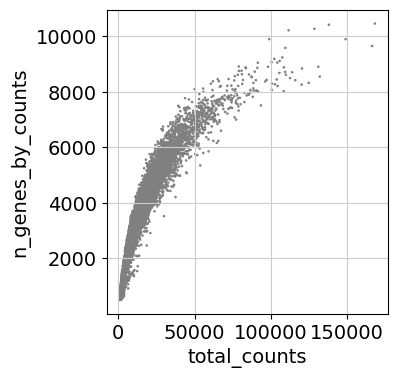

In [13]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")


In [14]:
adata = adata[adata.obs.n_genes_by_counts < 7000, :]
adata = adata[adata.obs.total_counts < 45000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
adata = adata[adata.obs.pct_counts_ribo < 40, :]
adata = adata[adata.obs.pct_counts_hb < 2, :].copy()

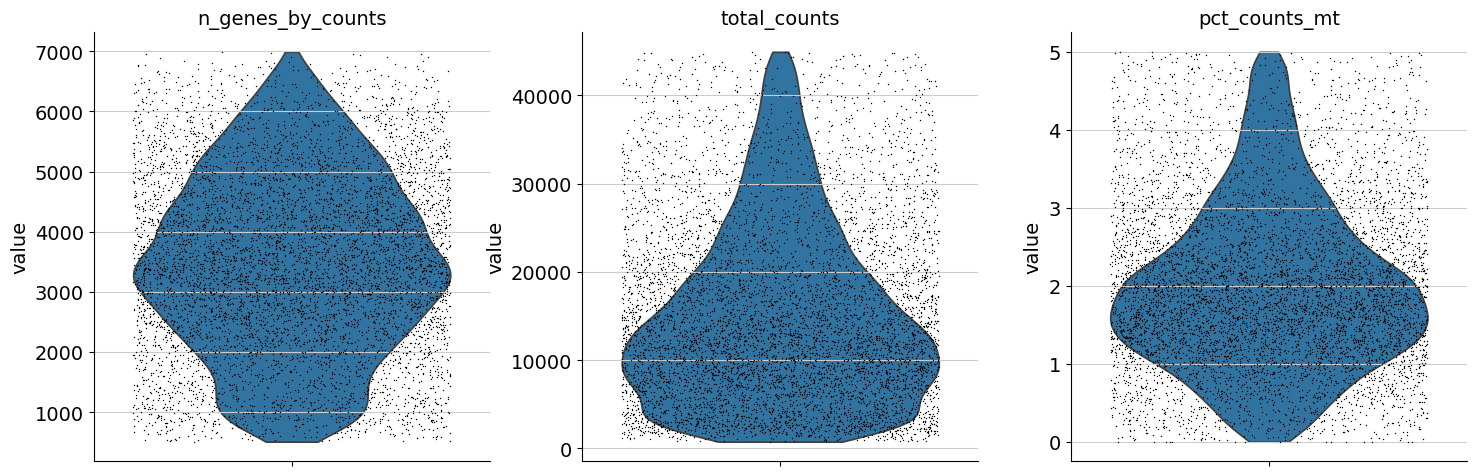

In [15]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

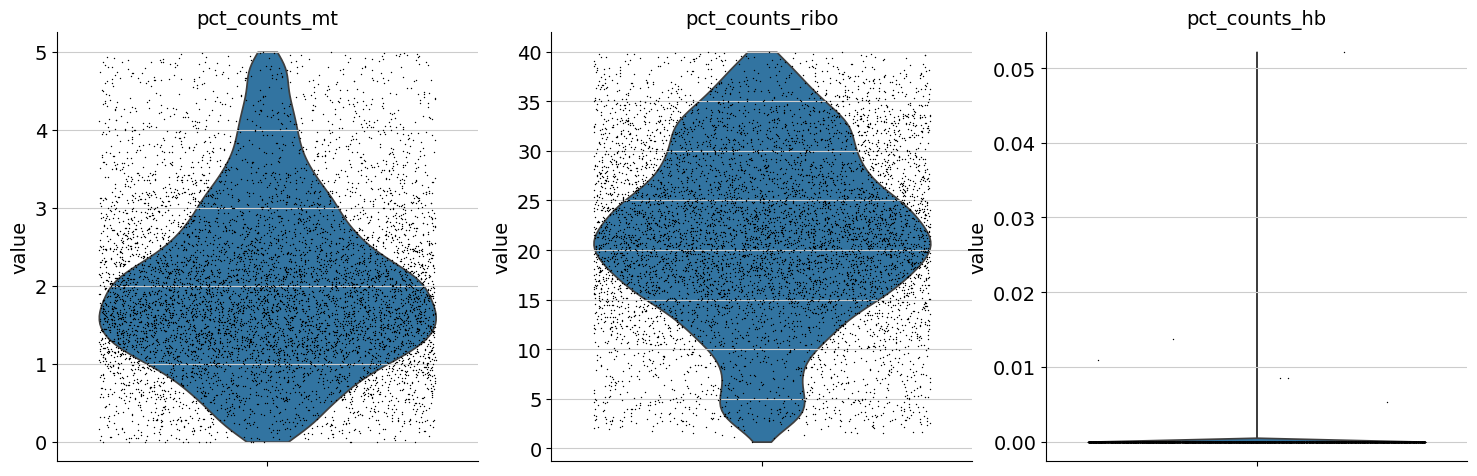

In [16]:
sc.pl.violin(
    adata,
    ["pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

In [17]:
adata.layers["counts"] = adata.X.copy()

In [18]:
#save object and go to command line to run BigSur
adata.write('cellplex7.h5ad')

In [5]:
## start in bioportal ATAC, then go to SysBio24 

In [3]:
adata = sc.read_h5ad('cellplex7.h5ad')

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
adata.raw = adata

In [6]:
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)

In [7]:
sc.tl.pca(adata, svd_solver="arpack")

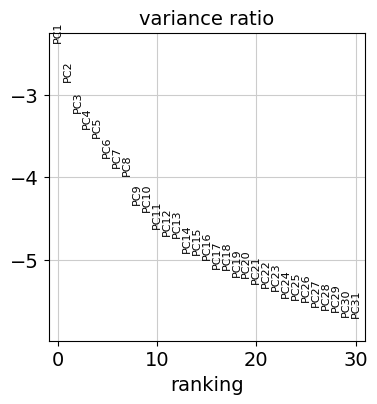

In [8]:
sc.pl.pca_variance_ratio(adata, log=True)

In [9]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [10]:
sc.tl.leiden(
    adata,
    resolution=0.1,
    random_state=0,
    n_iterations=2,
    directed=False,
)

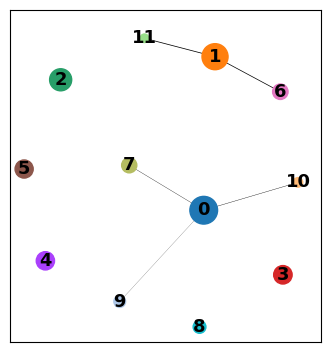

In [11]:
sc.tl.paga(adata)
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos='paga')

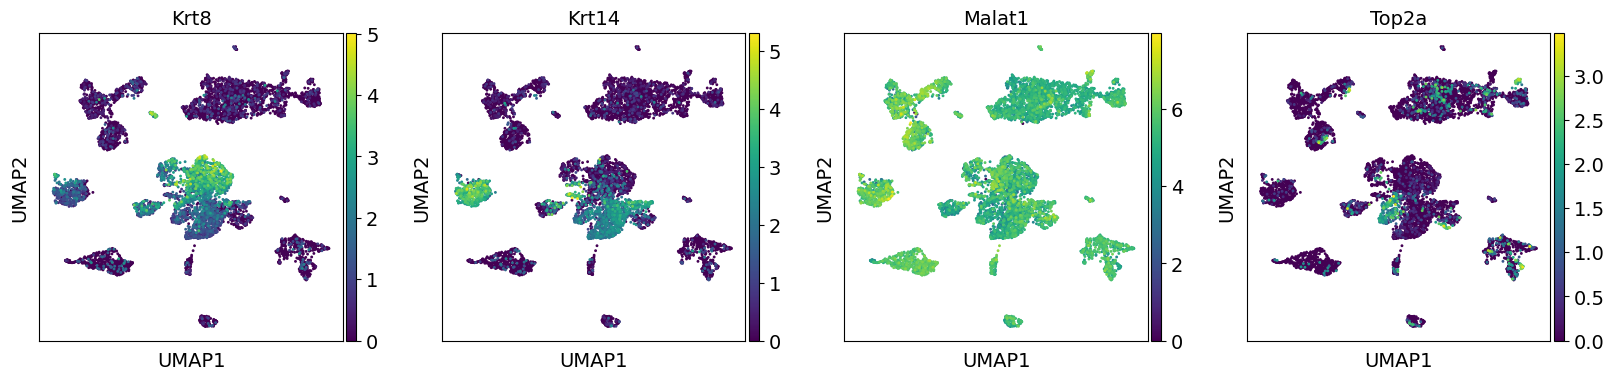

In [12]:
sc.pl.umap(adata, color=["Krt8", "Krt14", "Malat1", "Top2a"])

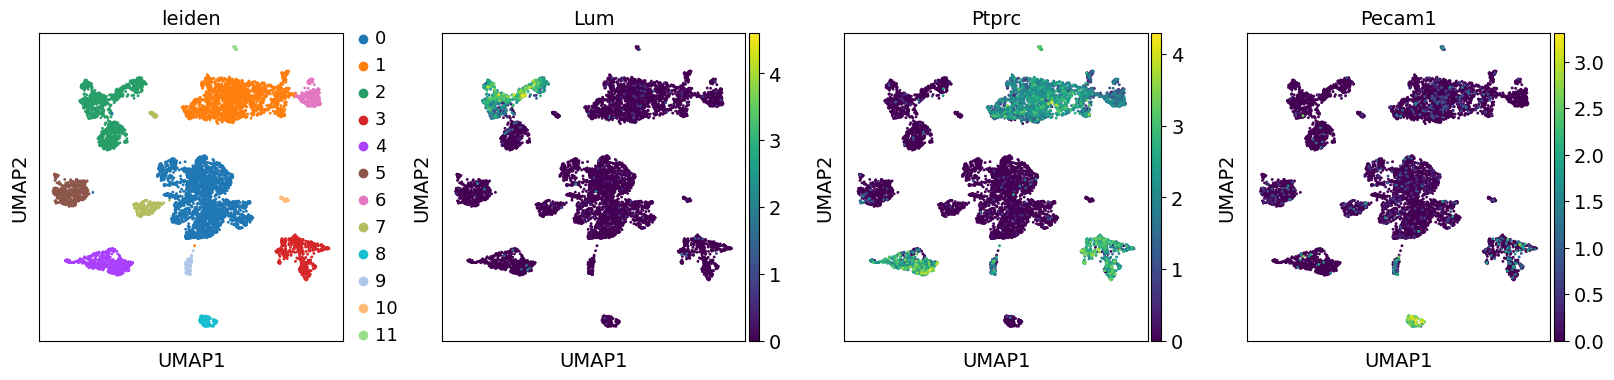

In [13]:
sc.pl.umap(adata, color=["leiden", "Lum", "Ptprc", "Pecam1"])

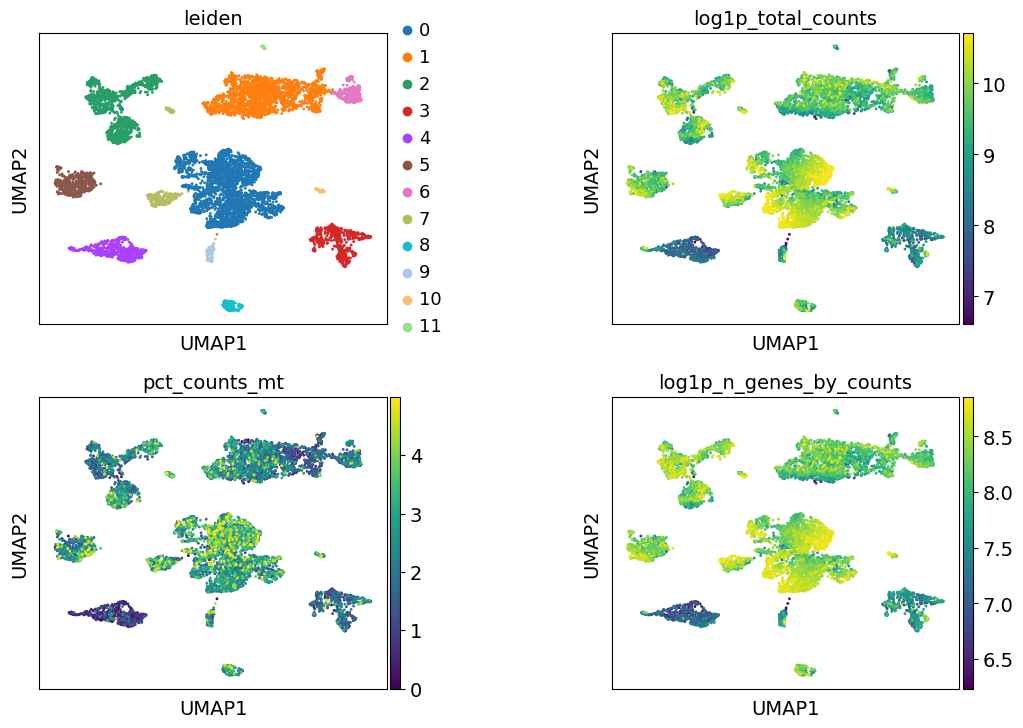

In [14]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [15]:
for res in [0.1, 0.2, 0.5]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res:4.2f}", resolution=res
    )

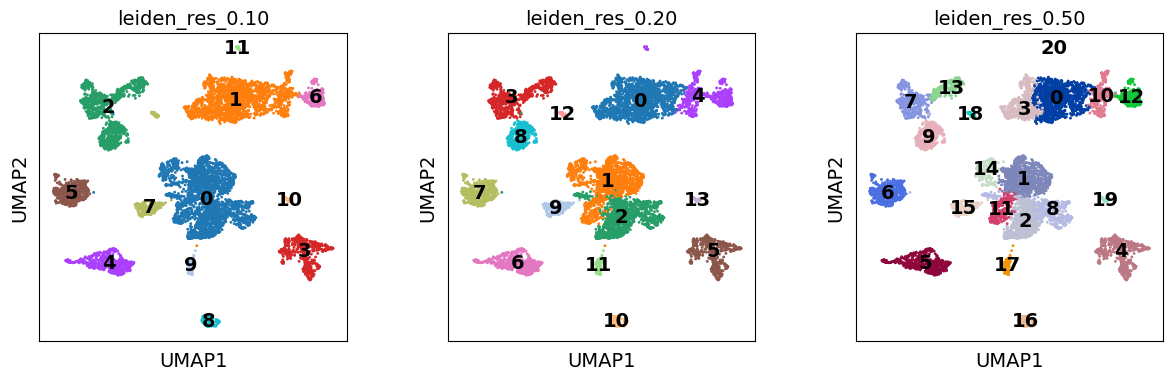

In [16]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50"],
    legend_loc="on data",
)

In [17]:
sc.tl.leiden(
    adata,
    resolution=0.10,
    random_state=0,
    n_iterations=2,
    directed=False,
)

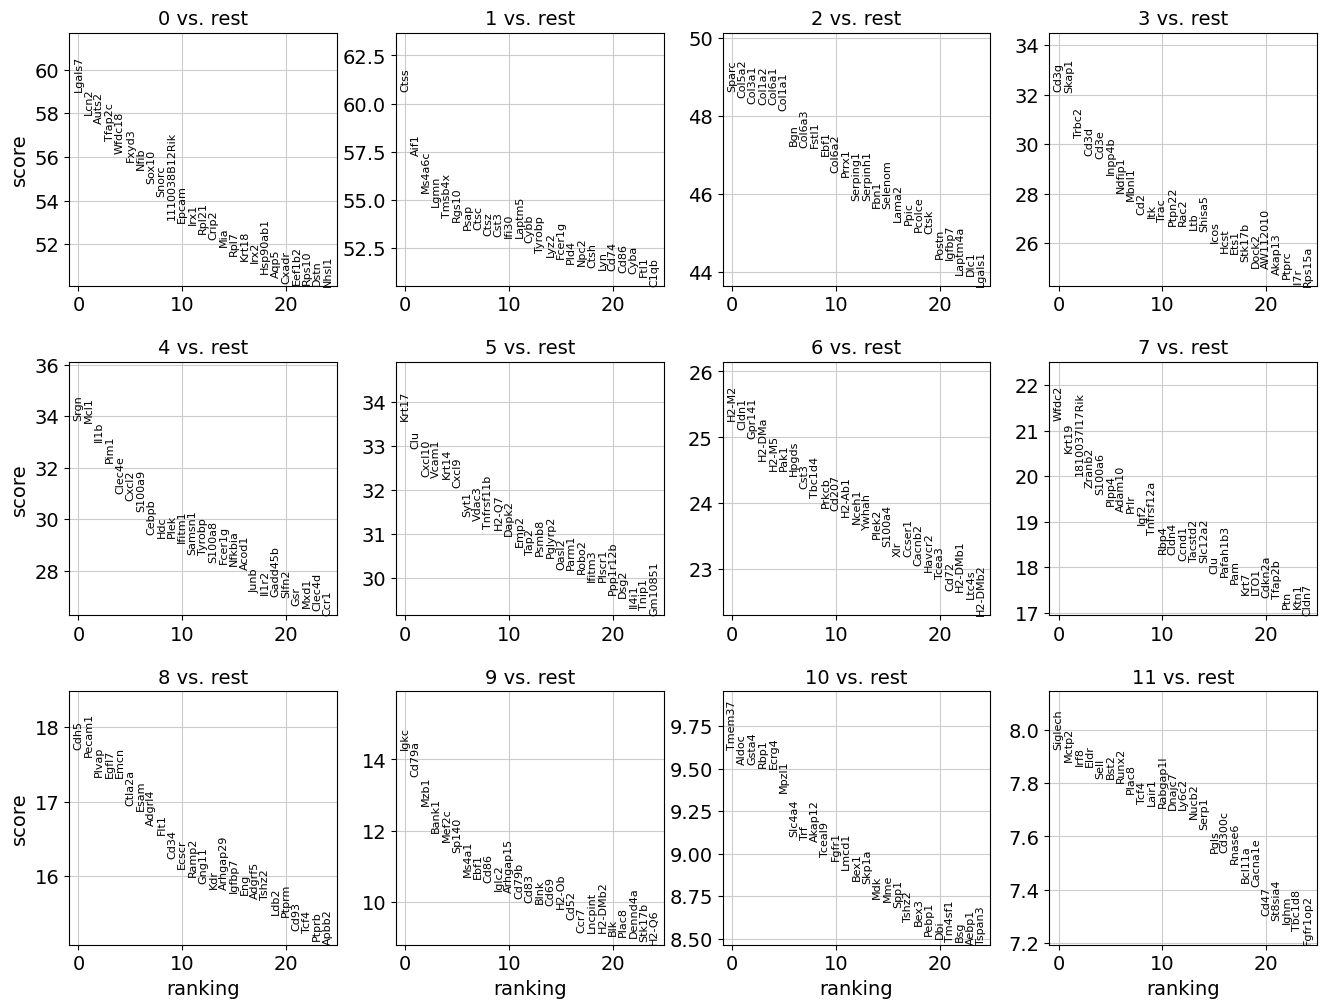

In [18]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [19]:
marker_genes = {
    "Proliferating": ["Top2a", "Mki67"],
    "Tumor": ["S100a14", "Cdkn2a"],
    "Basal": ["Krt5", "Krt14", "Trp63", "Tagln", "Acta2", "Mylk"],
    "Fibroblasts": ["Lum", "Dcn"],
    "Myeloid": ["Cd74"],
    "Tcells": ["Il7r"],
    "Bcells": ["Igkc"],
    "Neutrophils": ["Ptprc","Retnlg","Cxcr2","Ly6g","Mmp8"],
    "LumSec": ["Kit", "Krt8", "Krt18","Elf5"],
    "LumHR": ["Prlr", "Areg", "Esr1", "Pgr", "Erbb2", "Krt19"],
    "Pericytes": ["Rgs5"],
    "VSMC": ["Synm","Rergl","Pln"],
    "Perifibro": ["Sept4", "Col12a1", "Col8a1", "F2r"],
    "Adipo": ["Tenm2","Fat3","Apod","Idi1","Msmo1","Ifi30","Cyp51"],
    "Schwann": ["Ecm1","Smoc2","Plp1","Mbp","Sox10","Ngfr"],
    "Endothelial": ["Pecam1"]
}

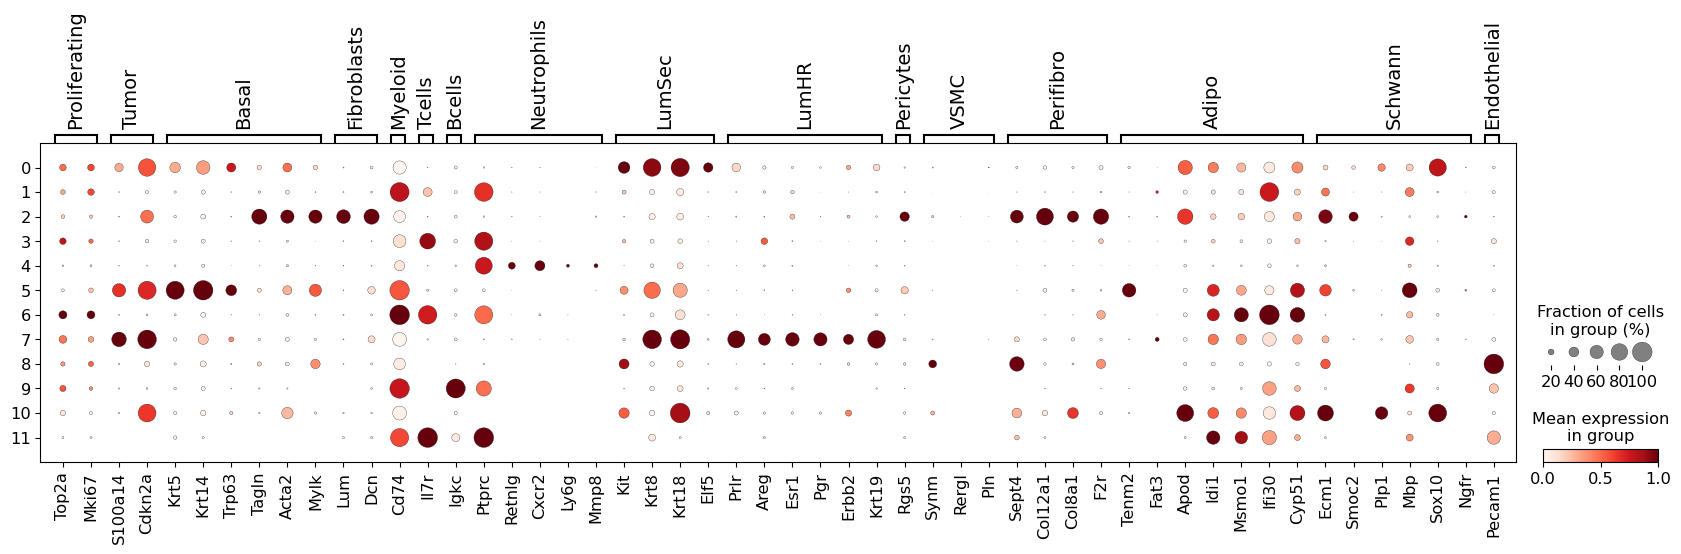

In [20]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.10", standard_scale="var")

In [21]:
adata.obs["cell_type"] = adata.obs["leiden_res_0.10"].map(
    {
        "0": "Tumor_LumSec",
        "1": "Myeloid",
        "2": "Perifibro",
        "3": "Tcells",
        "4": "Neutrophils",
        "5": "Tumor_Basal",
        "6": "Myeloid",
        "7": "Tumor_LumHR",
        "8": "Endothelial",
        "9": "Bcells",
        "10": "Adipo_or_schwann",
        "11": "Tcells"
    }
)

In [22]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")

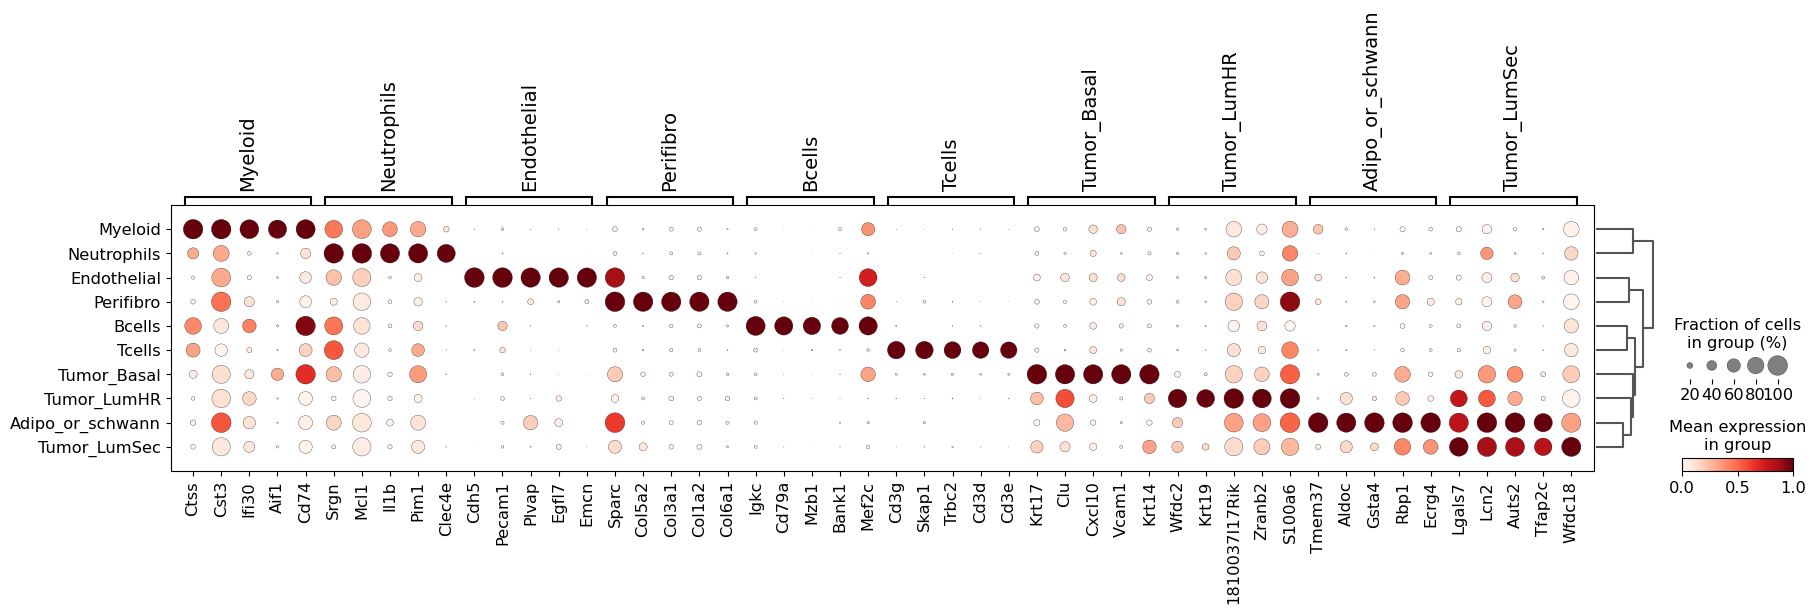

In [23]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type", standard_scale="var", n_genes=5
)

In [24]:
adata.write('/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/cellplex_7/cellplex7.h5ad')

In [33]:
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd

In [25]:
adata.obs.to_csv('cellplex7.adata.obs.metadata.csv')

In [26]:
hvg = sc.get.var_df(
    adata,
    keys=["highly_variable"]
)

hvg

,highly_variable
Sox17,True
St18,True
Prex2,True
Il17a,True
Kcnq5,True
...,...
Rnf138rt1,True
Tmsb4x,True
Frmpd4,True
Gm15245,True


In [27]:
hvg.to_csv('cellplex7.bigsur.hvg.csv')

In [28]:
clusters = sc.get.obs_df(
    adata,
    keys=["cell_type"]
)

clusters

,cell_type
AAACGAATCCCAGGAC-1,Myeloid
AAACGCTGTGTCATGT-1,Myeloid
AAAGGATTCTCTTGCG-1,Tcells
AAAGGGCAGCCGATAG-1,Myeloid
AAAGGGCGTCGTTATG-1,Tcells
...,...
TTTGGAGGTTCGTACA-1,Neutrophils
TTTGGTTTCAAGAGGC-1,Tumor_LumSec
TTTGTTGAGATTCGAA-1,Myeloid
TTTGTTGCATTGACTG-1,Tumor_LumHR


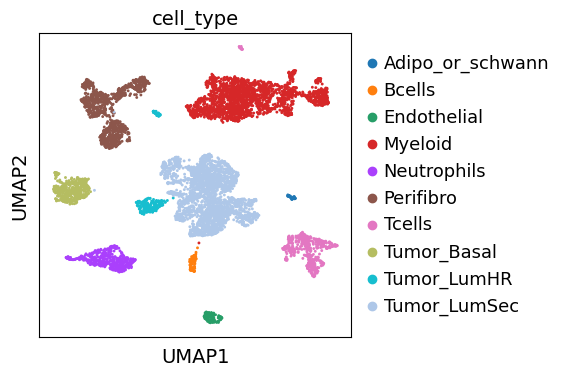

In [29]:
sc.pl.umap(
    adata,
    color=["cell_type"],
    wspace=0.5,
    ncols=2,
)

In [30]:
clusters.to_csv('cellplex7.bigsur.celltype.clusters.csv')